In [4]:
import warnings
warnings.filterwarnings("ignore")

In [5]:
import pandas as pd
import drawdata
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
widget = drawdata.ScatterWidget()
widget

In [7]:
data = widget.data_as_pandas

In [8]:
data.head()

""


In [9]:
data.shape

(0, 0)

In [10]:
data.shape

(0, 0)

# Explore Bagging

6 diffrent random forest with a single tree

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor

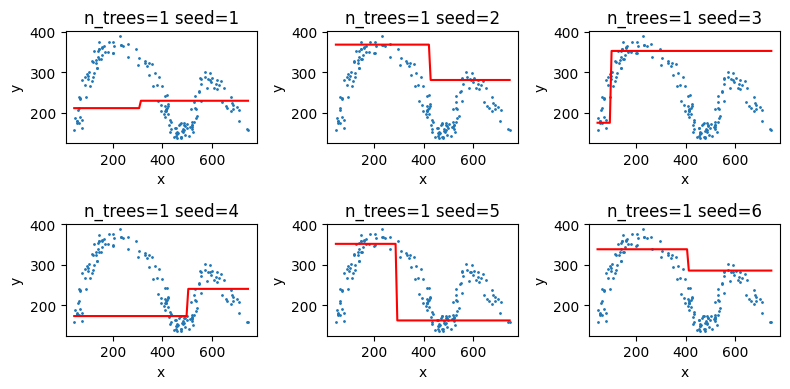

In [12]:
layout = """
123
456
"""

fig, axes = plt.subplot_mosaic(layout, figsize=(8, 4))
n_trees = [1] * 6

data = pd.read_csv('datasets/simple.csv')

for i, n_tree in enumerate(n_trees, start=1):
    ax = axes[str(i)]

    data.plot.scatter(
        x="x",
        y="y",
        ax=ax,
        title=f"n_trees={n_tree} seed={i}",
        s=1
    )

    clf = RandomForestRegressor(
        n_estimators=n_tree,
        max_depth=3,
        max_samples=0.01,
        random_state=i
    )

    clf.fit(data[["x"]], data["y"])

    x_pred = pd.DataFrame({
        "x": np.linspace(data.x.min(), data.x.max(), 100)
    })

    y_pred = clf.predict(x_pred)

    ax.plot(x_pred["x"], y_pred, c="red")

fig.tight_layout()
plt.show()





# random forest vs single tree

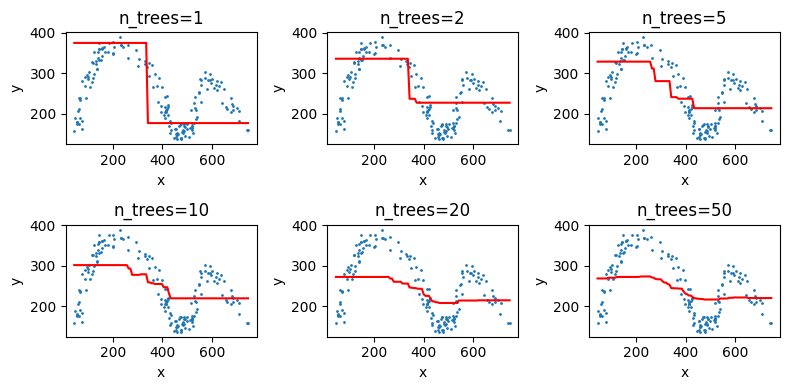

In [13]:
layout = """
123
456
"""

fig, axes = plt.subplot_mosaic(layout, figsize=(8, 4))
n_trees = [1, 2, 5, 10, 20, 50]

data = pd.read_csv('datasets/simple.csv')

for i, n_tree in enumerate(n_trees, start=1):
    ax = axes[str(i)]

    data.plot.scatter(
        x="x",
        y="y",
        ax=ax,
        title=f"n_trees={n_tree}",
        s=1
    )

    clf = RandomForestRegressor(
        n_estimators=n_tree,
        max_depth=3,
        max_samples=0.01,
        random_state=42
    )

    clf.fit(data[["x"]], data["y"])

    x_pred = pd.DataFrame({
        "x": np.linspace(data.x.min(), data.x.max(), 100)
    })

    y_pred = clf.predict(x_pred)



    ax.plot(x_pred["x"], y_pred, c="red")

fig.tight_layout()
plt.show()





In [14]:
from ipywidgets import interact, IntSlider, FloatSlider

In [15]:
def plot_random_forest(data_path, max_depth, max_samples):
    layouts = """
    123
    456
    """

    plt.close('all')

    fig, axs = plt.subplot_mosaic(layouts, figsize=(18, 4))

    n_trees = [1, 2, 5, 10, 20, 50]

    data = pd.read_csv(data_path)

    for i, n_tree in enumerate(n_trees, start=1):
        ax = axs[str(i)]

        data.plot.scatter(
            x="x",
            y="y",
            ax=ax,
            title=f"n_trees={n_tree}",
            s=1
        )

        clf = RandomForestRegressor(
            n_estimators=n_tree,
            max_depth=max_depth,
            max_samples=max_samples,
            random_state=42
        )

        clf.fit(data[["x"]], data["y"])

        x = pd.DataFrame({
            "x": np.linspace(data.x.min(), data.x.max(), 100)
        })

        for i, tree in enumerate(clf.estimators_):
            y = tree.predict(x)
            ax.plot(x, y, c="grey", alpha=0.9)

        y = clf.predict(x)
        ax.plot(x, y, c="red")

    fig.tight_layout()
    plt.show()

In [16]:
max_depth_slider = IntSlider(min=1, max=10, value=3, description="Max Depth")
max_sample_slider = FloatSlider(min=0.01, max=1.0, value=0.01, description="Max Samples")


interact(plot_random_forest,
data_path = "datasets/simple.csv",
max_depth = max_depth_slider,
max_samples = max_sample_slider)

interactive(children=(Text(value='datasets/simple.csv', description='data_path'), IntSlider(value=3, descripti…

<function __main__.plot_random_forest(data_path, max_depth, max_samples)>

___

In [17]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

from sklearn import set_config

In [18]:
set_config(transform_output="pandas")

In [19]:
adult_data = fetch_openml(data_id=1590)

In [20]:
X = adult_data. data
y = adult_data.target

In [21]:
X.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States


In [22]:
y

0        <=50K
1        <=50K
2         >50K
3         >50K
4        <=50K
         ...  
48837    <=50K
48838     >50K
48839    <=50K
48840    <=50K
48841     >50K
Name: class, Length: 48842, dtype: category
Categories (2, object): ['<=50K', '>50K']

In [23]:
adult = pd.read_parquet("datasets/adult.parquet")

In [24]:
X  =adult.drop(columns=["y"])
y = adult.y

In [25]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             48842 non-null  int64   
 1   workclass       46043 non-null  category
 2   fnlwgt          48842 non-null  int64   
 3   education       48842 non-null  category
 4   education-num   48842 non-null  int64   
 5   marital-status  48842 non-null  category
 6   occupation      46033 non-null  category
 7   relationship    48842 non-null  category
 8   race            48842 non-null  category
 9   sex             48842 non-null  category
 10  capital-gain    48842 non-null  int64   
 11  capital-loss    48842 non-null  int64   
 12  hours-per-week  48842 non-null  int64   
 13  native-country  47985 non-null  category
dtypes: category(8), int64(6)
memory usage: 2.6 MB


In [26]:
X.isna().sum()

age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
dtype: int64

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

In [28]:
categorical_features = X.select_dtypes(include=["category"]).columns
categorical_transformer = Pipeline(steps=[
("imputer", SimpleImputer(strategy='constant', fill_value='missing')),
("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))

])

In [29]:
categorical_transformer.fit_transform(X[categorical_features])

,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,workclass_missing,education_10th,education_11th,education_12th,education_1st-4th,education_5th-6th,education_7th-8th,education_9th,education_Assoc-acdm,education_Assoc-voc,education_Bachelors,education_Doctorate,education_HS-grad,education_Masters,education_Preschool,education_Prof-school,education_Some-college,marital-status_Divorced,marital-status_Married-AF-spouse,marital-status_Married-civ-spouse,marital-status_Married-spouse-absent,marital-status_Never-married,marital-status_Separated,marital-status_Widowed,occupation_Adm-clerical,occupation_Armed-Forces,occupation_Craft-repair,occupation_Exec-managerial,occupation_Farming-fishing,occupation_Handlers-cleaners,occupation_Machine-op-inspct,occupation_Other-service,...,native-country_China,native-country_Columbia,native-country_Cuba,native-country_Dominican-Republic,native-country_Ecuador,native-country_El-Salvador,native-country_England,native-country_France,native-country_Germany,native-country_Greece,native-country_Guatemala,native-country_Haiti,native-country_Holand-Netherlands,native-country_Honduras,native-country_Hong,native-country_Hungary,native-country_India,native-country_Iran,native-country_Ireland,native-country_Italy,native-country_Jamaica,native-country_Japan,native-country_Laos,native-country_Mexico,native-country_Nicaragua,native-country_Outlying-US(Guam-USVI-etc),native-country_Peru,native-country_Philippines,native-country_Poland,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia,native-country_missing
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,..

In [30]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier


In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [32]:

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_features)
    ]
)

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifer", DecisionTreeClassifier(random_state=42))
])

In [33]:
pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifer', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

In [34]:
predictions = pipeline.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print(f"Model Accuracy: {accuracy:.3f}")

Model Accuracy: 0.818


In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_features)
    ]
)

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifer", RandomForestClassifier(n_estimators=100, max_depth=20, max_samples=0.1, random_state=42))
])

pipeline.fit(X_train,y_train)

predictions = pipeline.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print(f"Model Accuracy: {accuracy:.3f}")

Model Accuracy: 0.832


In [36]:
# import numpy as np
# import pandas as pd

# from sklearn.pipeline import Pipeline
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.model_selection import RandomizedSearchCV
# from sklearn.metrics import accuracy_score

# pipeline = Pipeline(steps=[
#     ("preprocessor", preprocessor),
#     ("classifier", RandomForestClassifier(random_state=42, n_jobs=-1)),
# ])

# param_distributions = {
#     "classifier__n_estimators": np.arange(50, 801, 50),
#     "classifier__max_depth": [None, 3, 5, 8, 12, 20],
#     "classifier__min_samples_leaf": [1, 2, 4, 8],
#     "classifier__max_features": ["sqrt", "log2", None],
# }

# rnd = RandomizedSearchCV(
#     estimator=pipeline,
#     param_distributions=param_distributions,
#     n_iter=30,
#     scoring="accuracy",
#     cv=5,
#     random_state=42,
#     n_jobs=-1,
#     refit=True,
#     return_train_score=True,
# )

# rnd.fit(X_train, y_train)

# print("Best params:", rnd.best_params_)
# print("Best CV accuracy:", rnd.best_score_)

# y_pred = rnd.predict(X_test)
# print("Test accuracy:", accuracy_score(y_test, y_pred))

# pd.DataFrame(rnd.cv_results_).sort_values("rank_test_score").head(10)[
#     ["mean_test_score", "std_test_score", "mean_train_score", "params"]
# ]

# Boosting and Grandient Boosting



In [37]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import AdaBoostRegressor, AdaBoostClassifier
from sklearn.linear_model import LinearRegression

import warnings

warnings.filterwarnings('ignore')

In [38]:
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifer", AdaBoostClassifier())
])

pipeline.fit(X_train, y_train)

predictions = pipeline.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print(f"Model Accuracy: {accuracy:.3f}")

Model Accuracy: 0.824


## Gradient boosting

In [39]:
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier


In [40]:
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifer", GradientBoostingClassifier())
])

pipeline.fit(X_train, y_train)

predictions = pipeline.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print(f"Model Accuracy: {accuracy:.3f}")

Model Accuracy: 0.833


### Hyperparameter Tuning for Boosting Models

1. Wiedza domenowa -> ogranicz przestrzeń
2. Random search -> eksploruj globalnie
3. Grid search - doprecyzuj lokalnie
4. Pipeline -> kontroluj leakage
5. CV -> stabilizuj porówanania
6. Multi-metric -> swiadome kompromisy
7. Analiza wyników -> ucz się, nie tylko wybieraj

In [41]:
n_estimators = [50, 100, 150, 200, 300] # pojemnść modelu
learning_rate_space = [0.03, 0.05, 0.1] # krok
max_detph_space =[2, 3]

In [42]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, accuracy_score, f1_score

In [48]:
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=42))
])

param_distributions = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__learning_rate": [0.01, 0.05, 0.1],
    "classifier__max_depth": [3, 5],
    "classifier__subsample": [0.8, 1.0]
}

scoring ={
    "accuracy": make_scorer(accuracy_score),
    "f1": make_scorer(f1_score, average="weighted")
}

random_search = RandomizedSearchCV(
    estimator = pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    scoring=scoring,
    refit= "f1",
    cv= 5,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__learning_rate': [0.01, 0.05, ...], 'classifier__max_depth': [3, 5], 'classifier__n_estimators': [100, 200, ...], 'classifier__subsample': [0.8, 1.0]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","{'accuracy': make_scorer(a...hod='predict'), 'f1': make_scorer(f...rage=weighted)}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the s

In [49]:
best_params = random_search.best_params_

grid_param_space = {
    "classifier__n_estimators": [
        best_params["classifier__n_estimators"] - 50,
        best_params["classifier__n_estimators"],
        best_params["classifier__n_estimators"] + 50,
    ],
    "classifier__learning_rate": [
        best_params["classifier__learning_rate"] * 0.8,
        best_params["classifier__learning_rate"],
        best_params["classifier__learning_rate"] * 1.2,
    ],
    "classifier__max_depth": [best_params["classifier__max_depth"]],
    "classifier__subsample": [best_params["classifier__subsample"]],
}

In [47]:
from sklearn.model_selection import GridSearchCV

In [50]:
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=grid_param_space,
    scoring= scoring,
    refit="f1",
    cv=5,
    n_jobs=-1

)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__learning_rate': [0.08000000000000002, 0.1, ...], 'classifier__max_depth': [5], 'classifier__n_estimators': [50, 100, ...], 'classifier__subsample': [0.8]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': make_scorer(a...hod='predict'), 'f1': make_scorer(f...rage=weighted)}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verb

In [52]:
results = pd.DataFrame(grid_search.cv_results_)

results[
    [
        "mean_test_accuracy",
        "mean_test_f1",
        "param_classifier__n_estimators",
        "param_classifier__learning_rate",
        "param_classifier__max_depth",
        "param_classifier__subsample"
    ]
].sort_values("mean_test_f1", ascending=False)

,mean_test_accuracy,mean_test_f1,param_classifier__n_estimators,param_classifier__learning_rate,param_classifier__max_depth,param_classifier__subsample
5,0.833455,0.826351,150,0.10,5,0.8
8,0.832607,0.825886,150,0.12,5,0.8
4,0.833046,0.825587,100,0.10,5,0.8
7,0.832549,0.825518,100,0.12,5,0.8
2,0.832724,0.825488,150,0.08,5,0.8
1,0.832373,0.824483,100,0.08,5,0.8
6,0.831905,0.823238,50,0.12,5,0.8
3,0.831847,0.823092,50,0.10,5,0.8
0,0.831320,0.821750,50,0.08,5,0.8


XgBoosting

In [54]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from xgboost import XGBRegressor

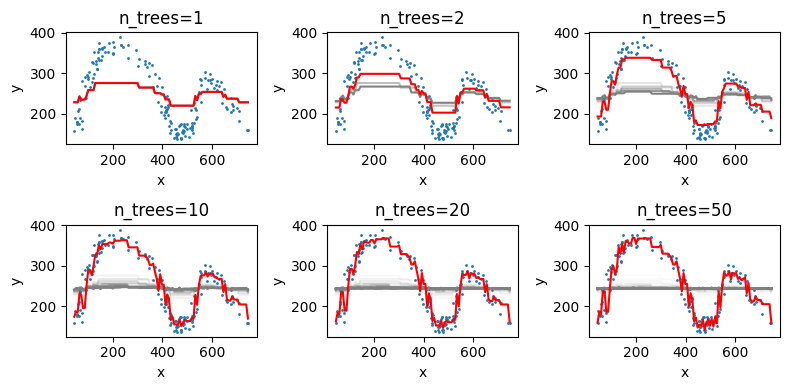

In [57]:
layouts = """
123
456
"""

fig, axs = plt.subplot_mosaic(layouts, figsize=(8,4))

n_trees = [1, 2, 5, 10, 20, 50]

data = pd.read_csv("datasets/simple.csv")

for i, n_tree in enumerate(n_trees, start=1):
    ax= axs[str(i)]

    data.plot.scatter(x="x", y="y", ax=ax, title=f"n_trees={n_tree}", s=1)

    rf = XGBRegressor(
        n_estimators=n_tree,
        max_deptg=2,
        random_state=42
    )
    rf.fit(data["x"], data["y"])
    x = pd.DataFrame({"x": np.linspace(data.x.min(), data.x.max(), 100)})

    for z, j in enumerate(range(n_tree)):
        y= rf.predict(x, iteration_range=(j, j+1))
        ax.plot(x, y, c='grey', alpha=(z + 1) / n_tree)

    y = rf.predict(x)
    ax.plot(x, y, c='red')

plt.tight_layout()

In [ ]:
from xgboost import XGBClassifier


In [73]:
model = XGBClassifier(enable_categorical=True)
model.fit(X_train, y_train==">50K")

accuracy = accuracy_score(y_test==">50K", model.predict(X_test))
print(f"Model accuracy: {accuracy:.3f}")

Model accuracy: 0.874


In [74]:
from sklearn.metrics import make_scorer, accuracy_score, f1_score

In [79]:
y_proba = model.predict_proba(X_test)[:, 1]

y_pred = (y_proba >= 0.5)
y_pred

array([False, False, False, ..., False, False, False], shape=(14653,))

In [80]:
f1 = f1_score(y_test==">50K", model.predict(X_test))
print(f"Model f1_score: {f1:.3f}")

Model f1_score: 0.715


In [83]:
model = XGBClassifier(enable_categorical=True, max_depth=3)
model.fit(X_train, y_train==">50K")

accuracy = accuracy_score(y_test==">50K", model.predict(X_test))
f1 = f1_score(y_test==">50K", model.predict(X_test))
print(f"Model accuracy: {accuracy:.3f}")
print(f"Model f1_score: {f1:.3f}")

Model accuracy: 0.877
Model f1_score: 0.718
